In [10]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [11]:
# Carrega os dados do CSV   . Delimiter=',' indica que as colunas são separadas por virgula
# skiprows=2 para pular as duas linhas de cabeçalho/comentário
dataset = np.loadtxt("tumores.csv", delimiter=',', skiprows=1)

# separa as colunas de características (features) e a coluna de rótulos (labels)
# X_train recebe todas as linhas, mas apenas as duas primeiras colunas (indice 0 e 1)
X_train = dataset[:, :2]

# y_train recebe todas as linhas, mas apenas a última coluna (indice2)
# .astype(int) para garantir que as classes sejam tratadas como inteiros
y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train):")
(X_train[:5])
print("\nAmostra dos rótulos(y_train):")
print(y_train[:5])

Amostra das características (X_train):

Amostra dos rótulos(y_train):
[0 0 0 0 0]


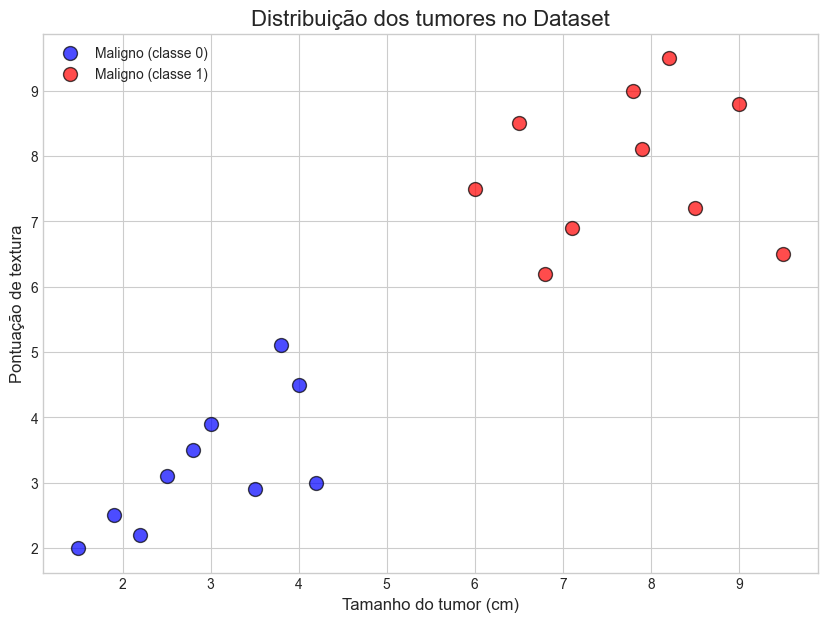

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# plota os pontos benignos (Classe 0)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train ==0, 1],
           c='blue', s=100, edgecolors='k', alpha=0.7, label='Maligno (classe 0)')

# plota os pontos benignos (Classe 1)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train ==1, 1],
           c='red', s=100, edgecolors='k', alpha=0.7, label='Maligno (classe 1)')

ax.set_title('Distribuição dos tumores no Dataset', fontsize=16)
ax.set_xlabel('Tamanho do tumor (cm)', fontsize=12)
ax.set_ylabel('Pontuação de textura', fontsize=12)
ax.legend()
plt.show()

In [13]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

In [14]:
def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos proximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    # ordena a lista de distancias em ordem crescente
    distancias.sort(key=lambda x: x[0])

    # retorna os k vizinhos mais proximos (seus rótulos)
    vizinhos = [distancias[1] for distancia in distancias[:k]]
    return vizinhos

In [15]:
def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritario dos vizinhos"""
    
    # conta a ocorrencia de cada classe nos vizinhos
    contagem_votos = Counter(vizinhos)

    # retorna a classe mais comum
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

In [16]:
# ponto que queremos classificar
novo_tumor = np.array([5.5, 6.0])
k = 5

# encontrar os vizinhos e fazer a previsão
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_tumor, k)
previsao_final = prever_classificacao(vizinhos_proximos)

# mapeia o resultado para um texto explicativo
resultado_texto = "Benigno" if previsao_final == 0 else "Maligno"

print(f"O novo tumor tem as características: {novo_tumor}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("----------------------------------------------------------")
print(f"\n--> previsão final: O novo tumor é classificado como {resultado_texto} (classe {previsao_final})")

O novo tumor tem as características: [5.5 6. ]
O valor de 'k' escolhido foi: 5
As classes dos vizinhos mais próximos são: [(np.float64(1.5811388300841898), np.int64(1)), (np.float64(1.5811388300841898), np.int64(1)), (np.float64(1.5811388300841898), np.int64(1)), (np.float64(1.5811388300841898), np.int64(1)), (np.float64(1.5811388300841898), np.int64(1))]
----------------------------------------------------------

--> previsão final: O novo tumor é classificado como Maligno (classe (np.float64(1.5811388300841898), np.int64(1)))


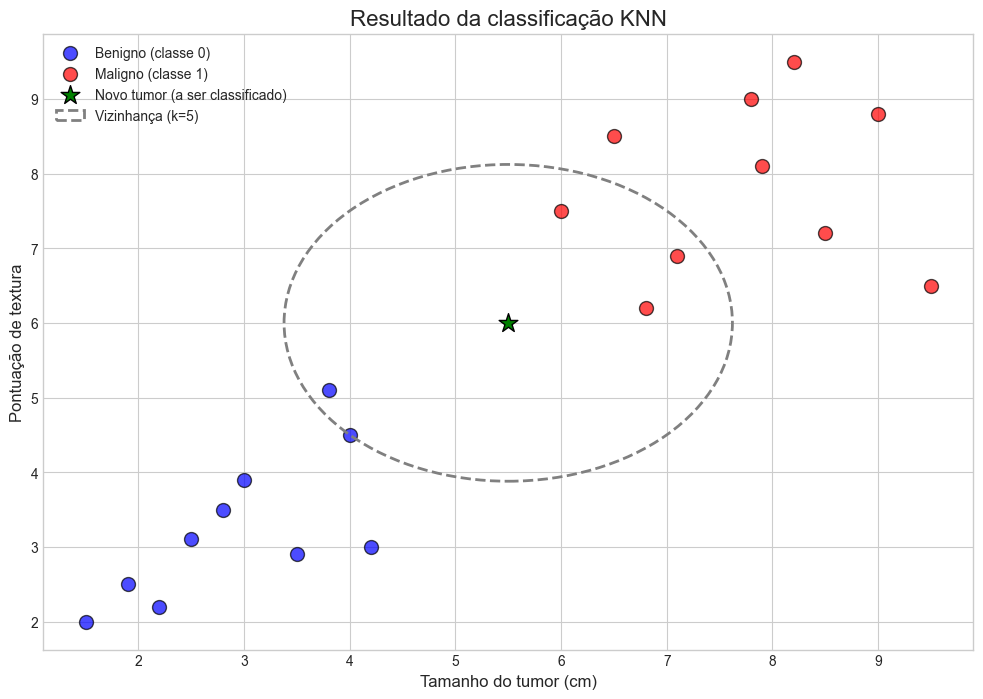

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))

#plotando os pontos de dados de treinamento
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='blue', s=100, edgecolor='k', alpha=0.7, label='Benigno (classe 0)')

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='red', s=100, edgecolor='k', alpha=0.7, label='Maligno (classe 1)')

# plotando o novo ponto de dados a ser classificado
ax.scatter(novo_tumor[0], novo_tumor[1], c='green', s=200,
            edgecolor='k', marker='*', label='Novo tumor (a ser classificado)')

# destaque para os vizinhos mais próximos
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_tumor) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]

# desenhando um círculo que engloba os vizinhos
distancia_maxima = calcular_distancia_euclidiana(novo_tumor, pontos_vizinhos[-1])
circulo = plt.Circle(novo_tumor, distancia_maxima, color='gray', fill=False,
                     linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

# configurações do gráfico
ax.set_title('Resultado da classificação KNN', fontsize=16)
ax.set_xlabel('Tamanho do tumor (cm)', fontsize=12)
ax.set_ylabel('Pontuação de textura', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
plt.show()